# Assignment 2

### Question 1

In [10]:
import numpy as np

test_array = np.arange(16)
new_array = test_array.reshape(2,8)

print("Num of dimensions is: ", new_array.ndim)
print("Shape is: ", new_array.shape)
print("Type is: ", new_array.dtype)

print("sum w/ axis = 0 = ", new_array.sum(axis = 0))
print("sum w/ axis = 1 = ", new_array.sum(axis = 1))

scaler = np.arange(8)
new_array_two = new_array * scaler
print(new_array)
print(scaler)
print(new_array_two)

Num of dimensions is:  2
Shape is:  (2, 8)
Type is:  int64
sum w/ axis = 0 =  [ 8 10 12 14 16 18 20 22]
sum w/ axis = 1 =  [28 92]
[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]]
[0 1 2 3 4 5 6 7]
[[  0   1   4   9  16  25  36  49]
 [  0   9  20  33  48  65  84 105]]


The difference between axis = 0 and axis = 1 is that when you sum across axis = 0, it sums vertically down the same column (across different rows), while when you sum across axis =1, it sums horizontally across the same row (across different columns). 


### Question 2

In [11]:
rng = np.random.default_rng(seed = 42)
total_steps = np.zeros((5,500))
for i in range(5):
    total_steps[i,:] = rng.choice([-1,1], size = 500, replace = True)

positions = total_steps.cumsum(axis = 1)
print(positions)

[[ -1.   0.   1. ... -12. -11. -12.]
 [ -1.   0.   1. ...  28.  29.  30.]
 [  1.   2.   3. ...   6.   5.   6.]
 [  1.   0.  -1. ... -18. -19. -20.]
 [  1.   0.  -1. ... -28. -29. -28.]]


The shape of the positions array is [5,500]. Each row represents a distinct "walk". Each column in each row represents the specific "location" of that walk at each specific "time" and is obtained by summing up all previous steps before it- for example, the initial position is just gotten from the initial total_steps array. Each subsequent "position" is obtained by summing all the previous steps before it- for example, for an row of steps that looks like [0, 1, -1], the initial position would just be 0, the first position would be 0 + 1 = 1, and the second position would be 0 + 1 - 1= 0, giving a position row of [0, 1, 0]. Thus, the number in the last column of each independent walk would represent the position of the object after the entire walk is finished. 

### Question 3

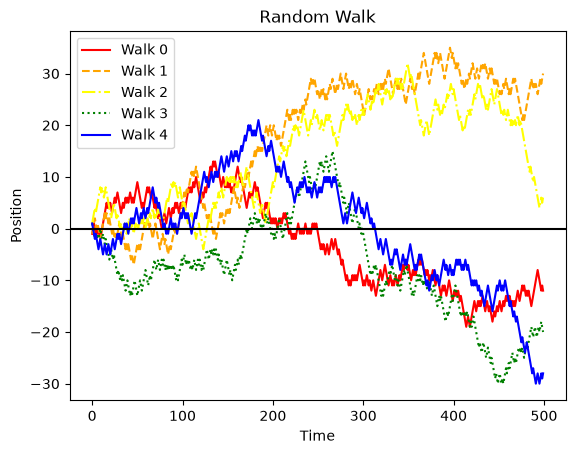

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(positions[0,:], label = 'Walk 0', linestyle = 'solid', color = 'red')
ax.plot(positions[1,:], label = 'Walk 1', linestyle = '--', color = 'orange')
ax.plot(positions[2,:], label = 'Walk 2', linestyle = '-.', color = 'yellow')
ax.plot(positions[3,:], label = 'Walk 3', linestyle = ':', color = 'green')
ax.plot(positions[4,:], label = 'Walk 4', linestyle = 'solid', color = 'blue')
ax.axhline(color = 'black')

ax.set_title('Random Walk')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.legend()

### Question 4

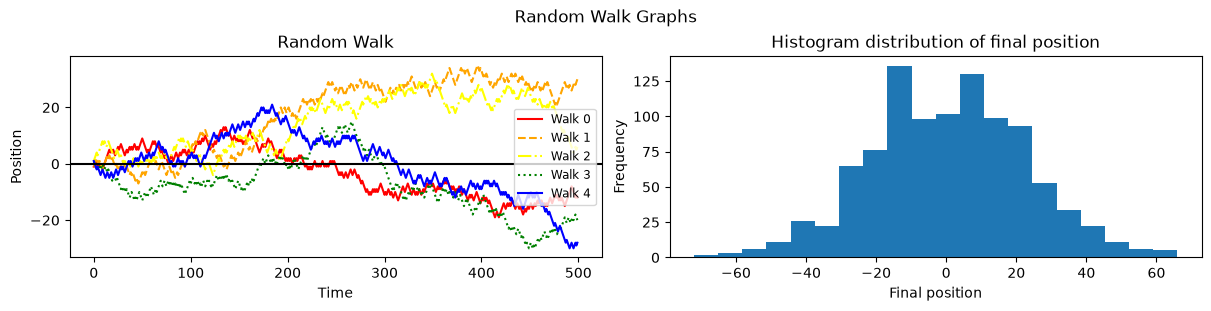

In [13]:
total_steps_second = np.zeros((1000,500))
for i in range(1000):
    total_steps_second[i,] = rng.choice([-1,1], size = 500, replace = True)

positions_two = total_steps_second.cumsum(axis = 1)

fig, axes = plt.subplots(1,2, figsize = (12,3), layout = 'constrained')
axes[0].plot(positions[0,:], label = 'Walk 0', linestyle = 'solid', color = 'red')
axes[0].plot(positions[1,:], label = 'Walk 1', linestyle = '--', color = 'orange')
axes[0].plot(positions[2,:], label = 'Walk 2', linestyle = '-.', color = 'yellow')
axes[0].plot(positions[3,:], label = 'Walk 3', linestyle = ':', color = 'green')
axes[0].plot(positions[4,:], label = 'Walk 4', linestyle = 'solid', color = 'blue')
axes[0].axhline(color = 'black')

axes[0].set_title('Random Walk')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position')
axes[0].legend(fontsize = 'small')

axes[1].hist(positions_two[:,499], bins = 20)
axes[1].set_xlabel('Final position')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram distribution of final position')

fig.suptitle('Random Walk Graphs')
fig.savefig('random_walks.png')